<a href="https://colab.research.google.com/github/Keshusrm/DeepLearning/blob/main/Lab10_Transfer_Learning_AlexNet_VGG16_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Lab: Transfer Learning Hands-on — Fine-tuning Pre-trained AlexNet and VGG-16

### Objective
In this lab, you will use **transfer learning** to classify images from the downloaded pet dataset using two ImageNet-pretrained CNNs:

1. **AlexNet**
2. **VGG-16**

You will:
- Download and prepare a small image classification dataset automatically, then load it using `ImageFolder`.
- Apply the preprocessing required by ImageNet-pretrained models.
- Replace the original 1000-class classifier with a classifier for your own dataset.
- Fine-tune the pretrained networks.
- Evaluate the models using accuracy and a confusion matrix.
- Visualize **intermediate feature maps** from important convolutional layers.
- Compare the performance of AlexNet and VGG-16.

> **Important:** This notebook uses torchvision's current pretrained-model API. If your installed torchvision version uses a different API, use the equivalent pretrained-weight option.



## 1. Background: What is Transfer Learning?

Training a deep CNN from scratch requires a large amount of labeled data and considerable computational resources.

In **transfer learning**, we start with a model that has already learned useful visual representations from a large dataset such as ImageNet.

For this lab:

**ImageNet → Pre-trained CNN → Replace final classifier → Train on custom dataset**

The early convolutional layers generally learn low-level visual patterns such as:
- edges
- corners
- textures
- simple shapes

Deeper layers learn increasingly task-specific and semantic representations.

### Two common approaches

**Feature extraction**
- Freeze most/all pretrained layers.
- Train only the new classifier.

**Fine-tuning**
- Start from pretrained weights.
- Replace the classifier.
- Allow some or all pretrained layers to update using the new dataset.

In this lab, we will perform **fine-tuning**.



## 2. Expected Dataset Structure

The notebook automatically creates the following ImageFolder-style structure:

```text
custom_dataset/
│
├── train/
│   ├── class_1/
│   │   ├── image1.jpg
│   │   ├── image2.jpg
│   │   └── ...
│   │
│   ├── class_2/
│   │   ├── image1.jpg
│   │   └── ...
│   │
│   └── ...
│
├── val/
│   ├── class_1/
│   ├── class_2/
│   └── ...
│
└── test/
    ├── class_1/
    ├── class_2/
    └── ...
```

You may use **any custom image classification dataset** with two or more classes.

For example:

```text
custom_dataset/
├── train/
│   ├── cats/
│   └── dogs/
├── val/
│   ├── cats/
│   └── dogs/
└── test/
    ├── cats/
    └── dogs/
```

### Recommended split

A reasonable starting point is:

- Training: 70–80%
- Validation: 10–15%
- Testing: 10–15%

The classes must have the **same folder names** in train, validation, and test directories.


In [1]:

# 3. Import Required Libraries

import os
import copy
import time
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


PyTorch version: 2.11.0+cpu
CUDA available: False
Using device: cpu



## 3.1 Set the Dataset Path

Change `DATA_DIR` to the location of your dataset.

If your dataset is in the same folder as this notebook:

```text
lab_notebook.ipynb
custom_dataset/
```

then the following path is sufficient.


In [2]:
# 3.1 Download Oxford-IIIT Pet and prepare a small 4-class dataset

RAW_DATA_DIR = "./data"
DATA_DIR = "./pet_transfer_dataset"

SELECTED_CLASSES = [
    "Abyssinian",
    "Bengal",
    "Birman",
    "Bombay"
]

# Download the Oxford-IIIT Pet dataset.
# torchvision handles the download automatically.
pet_dataset = datasets.OxfordIIITPet(
    root=RAW_DATA_DIR,
    split="trainval",
    target_types="category",
    download=True
)

pet_test_dataset = datasets.OxfordIIITPet(
    root=RAW_DATA_DIR,
    split="test",
    target_types="category",
    download=True
)

print("Oxford-IIIT Pet downloaded/loaded successfully.")
print("Total trainval images:", len(pet_dataset))
print("Total test images:", len(pet_test_dataset))
print("Total original classes:", len(pet_dataset.classes))
print("Selected classes:", SELECTED_CLASSES)


def prepare_subset(source_dataset, selected_classes, output_root, split_name,
                   max_per_class=None, seed=42):
    """Copy selected Oxford-IIIT Pet images into ImageFolder-style folders."""

    rng = random.Random(seed)

    # torchvision's OxfordIIITPet stores filenames in _images.
    class_to_indices = {name: [] for name in selected_classes}

    for idx, target in enumerate(source_dataset._labels):
        class_name = source_dataset.classes[target]
        if class_name in class_to_indices:
            class_to_indices[class_name].append(idx)

    for class_name in selected_classes:
        indices = class_to_indices[class_name]
        rng.shuffle(indices)

        if max_per_class is not None:
            indices = indices[:max_per_class]

        class_dir = os.path.join(output_root, split_name, class_name)
        os.makedirs(class_dir, exist_ok=True)

        for idx in indices:
            image_path = source_dataset._images[idx]
            filename = os.path.basename(image_path)
            destination = os.path.join(class_dir, filename)

            if not os.path.exists(destination):
                shutil.copy2(image_path, destination)

    return class_to_indices


# Remove an old prepared dataset so that students can rerun this cell cleanly.
if os.path.exists(DATA_DIR):
    shutil.rmtree(DATA_DIR)

os.makedirs(DATA_DIR, exist_ok=True)

# Create train/validation from the official trainval portion.
trainval_indices = {name: [] for name in SELECTED_CLASSES}

for idx, target in enumerate(pet_dataset._labels):
    class_name = pet_dataset.classes[target]
    if class_name in trainval_indices:
        trainval_indices[class_name].append(idx)

rng = random.Random(42)

for class_name in SELECTED_CLASSES:
    indices = trainval_indices[class_name]
    rng.shuffle(indices)

    # 80% train, 20% validation
    split_point = int(0.8 * len(indices))
    train_indices = indices[:split_point]
    val_indices = indices[split_point:]

    for split_name, split_indices in [
        ("train", train_indices),
        ("val", val_indices)
    ]:
        class_dir = os.path.join(DATA_DIR, split_name, class_name)
        os.makedirs(class_dir, exist_ok=True)

        for idx in split_indices:
            image_path = pet_dataset._images[idx]
            filename = os.path.basename(image_path)
            shutil.copy2(
                image_path,
                os.path.join(class_dir, filename)
            )

# Create test split from the official test portion.
test_indices = {name: [] for name in SELECTED_CLASSES}

for idx, target in enumerate(pet_test_dataset._labels):
    class_name = pet_test_dataset.classes[target]
    if class_name in test_indices:
        test_indices[class_name].append(idx)

for class_name in SELECTED_CLASSES:
    class_dir = os.path.join(DATA_DIR, "test", class_name)
    os.makedirs(class_dir, exist_ok=True)

    for idx in test_indices[class_name]:
        image_path = pet_test_dataset._images[idx]
        filename = os.path.basename(image_path)
        shutil.copy2(
            image_path,
            os.path.join(class_dir, filename)
        )

TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR   = os.path.join(DATA_DIR, "val")
TEST_DIR  = os.path.join(DATA_DIR, "test")

print("\nPrepared dataset:")
for split_dir in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    print("\n", split_dir)
    for class_name in SELECTED_CLASSES:
        class_dir = os.path.join(split_dir, class_name)
        print(f"  {class_name}: {len(os.listdir(class_dir))} images")


100%|██████████| 792M/792M [00:31<00:00, 25.5MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 12.6MB/s]


Oxford-IIIT Pet downloaded/loaded successfully.
Total trainval images: 3680
Total test images: 3669
Total original classes: 37
Selected classes: ['Abyssinian', 'Bengal', 'Birman', 'Bombay']

Prepared dataset:

 ./pet_transfer_dataset/train
  Abyssinian: 80 images
  Bengal: 80 images
  Birman: 80 images
  Bombay: 76 images

 ./pet_transfer_dataset/val
  Abyssinian: 20 images
  Bengal: 20 images
  Birman: 20 images
  Bombay: 20 images

 ./pet_transfer_dataset/test
  Abyssinian: 98 images
  Bengal: 100 images
  Birman: 100 images
  Bombay: 88 images



## 4. Image Preprocessing

AlexNet and VGG-16 were originally trained on ImageNet.

Therefore, images should be transformed appropriately before being passed to the pretrained models.

For training we use:
- Resize
- Random crop
- Random horizontal flip
- Conversion to tensor
- ImageNet normalization

For validation/testing we avoid random augmentation so that evaluation is consistent.

### ImageNet normalization

```text
Mean = [0.485, 0.456, 0.406]
Std  = [0.229, 0.224, 0.225]
```

This normalization is important because the pretrained weights were learned using ImageNet-style preprocessing.


In [3]:
# 4.1 Image preprocessing

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

print("Transforms created.")
print("Model input: 3 × 224 × 224")


Transforms created.
Model input: 3 × 224 × 224


In [4]:

# 5. Load the Dataset

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset   = datasets.ImageFolder(VAL_DIR, transform=eval_transform)
test_dataset  = datasets.ImageFolder(TEST_DIR, transform=eval_transform)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)
print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))

assert train_dataset.class_to_idx == val_dataset.class_to_idx == test_dataset.class_to_idx,     "Class-to-index mapping is different between dataset splits!"


Classes: ['Abyssinian', 'Bengal', 'Birman', 'Bombay']
Number of classes: 4
Training images: 316
Validation images: 80
Test images: 386


In [5]:
# 5.1 Verify the image tensor dimensions

sample_tensor, sample_label = train_dataset[0]

print("One transformed image shape:", tuple(sample_tensor.shape))
print("Expected shape: (3, 224, 224)")

assert sample_tensor.shape == (3, 224, 224),     "The transformed image is not 3 × 224 × 224."

print("✓ Input dimension check passed.")


One transformed image shape: (3, 224, 224)
Expected shape: (3, 224, 224)
✓ Input dimension check passed.


In [6]:

# 6. Create DataLoaders

BATCH_SIZE = 32
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("DataLoaders created.")


DataLoaders created.


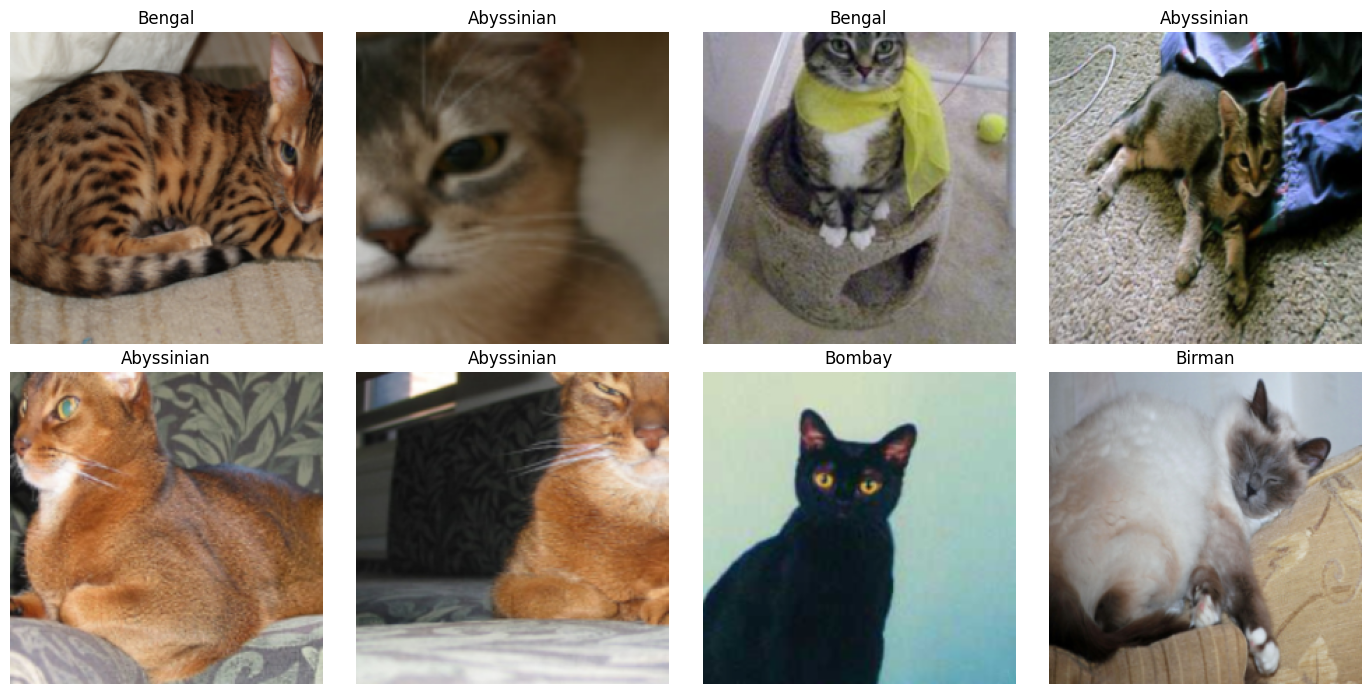

In [7]:

# 7. Visualize Sample Training Images

def denormalize(img):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return img * std + mean

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for i, ax in enumerate(axes.flat):
    image = denormalize(images[i]).clamp(0, 1)
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(class_names[labels[i].item()])
    ax.axis("off")

plt.tight_layout()
plt.show()



## 8. Load Pre-trained AlexNet

We first load **AlexNet with ImageNet-pretrained weights**.

The original AlexNet classifier was designed for **1000 ImageNet classes**.

Our custom dataset has `num_classes` classes, so we will replace the final classification layer.

### Important

We will use the model as a starting point rather than training a completely new CNN from random initialization.


In [8]:

# 8.1 Load pretrained AlexNet

alexnet_weights = models.AlexNet_Weights.DEFAULT
alexnet = models.alexnet(weights=alexnet_weights)

print(alexnet)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:02<00:00, 82.8MB/s]


AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [9]:

# 8.2 Replace AlexNet's final classifier

alexnet.classifier[6] = nn.Linear(
    alexnet.classifier[6].in_features,
    num_classes
)

alexnet = alexnet.to(device)

print("New AlexNet classifier:")
print(alexnet.classifier)


New AlexNet classifier:
Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=9216, out_features=4096, bias=True)
  (2): ReLU(inplace=True)
  (3): Dropout(p=0.5, inplace=False)
  (4): Linear(in_features=4096, out_features=4096, bias=True)
  (5): ReLU(inplace=True)
  (6): Linear(in_features=4096, out_features=4, bias=True)
)



## 9. Fine-tuning Strategy for AlexNet

We will use a **two-stage approach**:

### Stage 1 — Train the new classifier
Freeze the convolutional feature extractor and train the new classifier.

### Stage 2 — Fine-tune the network
Unfreeze the convolutional layers and continue training with a smaller learning rate.

This demonstrates an important practical idea:

> The pretrained model already contains useful visual features, so we do not necessarily need to learn everything from the beginning.


In [10]:

# 9.1 Utility function to freeze/unfreeze parts of AlexNet

def freeze_alexnet_features(model):
    for param in model.features.parameters():
        param.requires_grad = False

def unfreeze_alexnet_features(model):
    for param in model.features.parameters():
        param.requires_grad = True

freeze_alexnet_features(alexnet)

print("Trainable parameters after freezing features:")
print(sum(p.numel() for p in alexnet.parameters() if p.requires_grad))


Trainable parameters after freezing features:
54550532


In [11]:

# 10. Training and validation functions

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_predictions = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc, all_labels, all_predictions


In [12]:

# 10.1 Generic training loop

def fit_model(model, train_loader, val_loader, criterion, optimizer, epochs):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_weights = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    for epoch in range(epochs):
        start_time = time.time()

        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer
        )

        val_loss, val_acc, _, _ = evaluate(
            model, val_loader, criterion
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())

        elapsed = time.time() - start_time

        print(
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"Time: {elapsed:.1f}s"
        )

    model.load_state_dict(best_weights)
    return history


In [13]:

# 11. Stage 1: Train only the new AlexNet classifier

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, alexnet.parameters()),
    lr=1e-3
)

ALEXNET_STAGE1_EPOCHS = 3

alexnet_history_stage1 = fit_model(
    alexnet,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    ALEXNET_STAGE1_EPOCHS
)


Epoch 01/3 | Train Loss: 0.9915 | Train Acc: 0.7152 | Val Loss: 0.7292 | Val Acc: 0.7750 | Time: 30.1s
Epoch 02/3 | Train Loss: 0.4974 | Train Acc: 0.8481 | Val Loss: 0.6058 | Val Acc: 0.7750 | Time: 26.7s
Epoch 03/3 | Train Loss: 0.3578 | Train Acc: 0.8924 | Val Loss: 0.4522 | Val Acc: 0.7875 | Time: 26.1s


In [14]:

# 12. Stage 2: Fine-tune AlexNet

unfreeze_alexnet_features(alexnet)

# Use a much smaller learning rate for fine-tuning pretrained layers.
optimizer = optim.Adam(
    alexnet.parameters(),
    lr=1e-5,
    weight_decay=1e-4
)

ALEXNET_STAGE2_EPOCHS = 5

alexnet_history_stage2 = fit_model(
    alexnet,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    ALEXNET_STAGE2_EPOCHS
)


Epoch 01/5 | Train Loss: 0.2451 | Train Acc: 0.9146 | Val Loss: 0.2616 | Val Acc: 0.9000 | Time: 42.3s
Epoch 02/5 | Train Loss: 0.1981 | Train Acc: 0.9241 | Val Loss: 0.3031 | Val Acc: 0.8875 | Time: 41.5s
Epoch 03/5 | Train Loss: 0.1368 | Train Acc: 0.9399 | Val Loss: 0.2986 | Val Acc: 0.9000 | Time: 41.2s
Epoch 04/5 | Train Loss: 0.1331 | Train Acc: 0.9399 | Val Loss: 0.2711 | Val Acc: 0.9250 | Time: 41.4s
Epoch 05/5 | Train Loss: 0.1609 | Train Acc: 0.9367 | Val Loss: 0.2916 | Val Acc: 0.9250 | Time: 41.9s


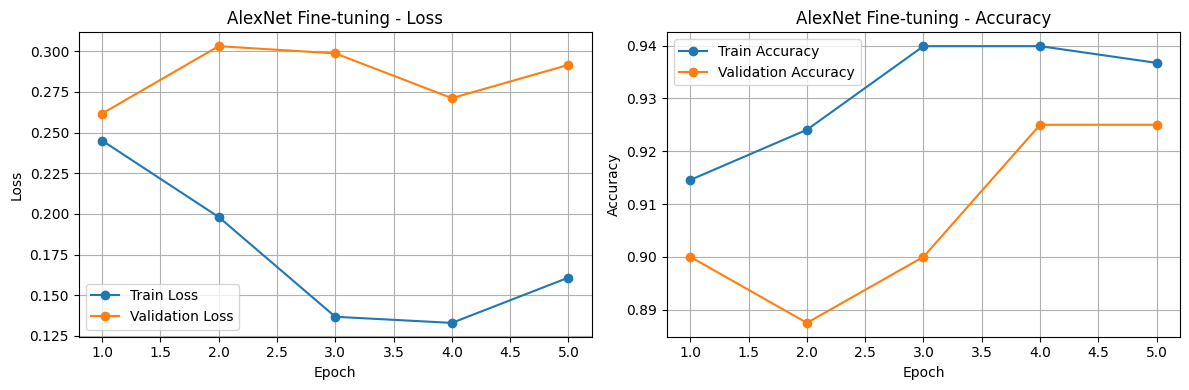

In [15]:

# 13. Plot AlexNet learning curves

def plot_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], marker="o", label="Train Loss")
    plt.plot(epochs, history["val_loss"], marker="o", label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + " - Loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], marker="o", label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], marker="o", label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title + " - Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_history(alexnet_history_stage2, "AlexNet Fine-tuning")



## 14. Load Pre-trained VGG-16

Now repeat the transfer-learning process using **VGG-16**.

VGG-16 has:
- 13 convolutional layers
- 3 fully connected layers
- 16 learnable layers in total

The original classifier was designed for 1000 ImageNet classes, so again we replace its final layer.


In [16]:

# 14.1 Load pretrained VGG-16

vgg_weights = models.VGG16_Weights.DEFAULT
vgg16 = models.vgg16(weights=vgg_weights)

print(vgg16)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:11<00:00, 47.3MB/s]


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [17]:

# 14.2 Replace VGG-16 final classifier

vgg16.classifier[6] = nn.Linear(
    vgg16.classifier[6].in_features,
    num_classes
)

vgg16 = vgg16.to(device)

print("New VGG-16 classifier:")
print(vgg16.classifier)


New VGG-16 classifier:
Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=4, bias=True)
)


In [18]:

# 15. Freeze VGG-16 convolutional features

for param in vgg16.features.parameters():
    param.requires_grad = False

print(
    "Trainable parameters:",
    sum(p.numel() for p in vgg16.parameters() if p.requires_grad)
)


Trainable parameters: 119562244


In [19]:

# 16. Stage 1: Train VGG-16 classifier

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, vgg16.parameters()),
    lr=1e-3
)

VGG_STAGE1_EPOCHS = 3

vgg_history_stage1 = fit_model(
    vgg16,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    VGG_STAGE1_EPOCHS
)


Epoch 01/3 | Train Loss: 1.0990 | Train Acc: 0.6741 | Val Loss: 0.9617 | Val Acc: 0.7375 | Time: 287.4s
Epoch 02/3 | Train Loss: 0.6873 | Train Acc: 0.8639 | Val Loss: 0.4314 | Val Acc: 0.8750 | Time: 285.7s
Epoch 03/3 | Train Loss: 0.6016 | Train Acc: 0.8924 | Val Loss: 0.7342 | Val Acc: 0.8750 | Time: 279.2s


In [ ]:

# 17. Stage 2: Fine-tune VGG-16

for param in vgg16.features.parameters():
    param.requires_grad = True

# Small learning rate because pretrained features are being fine-tuned.
optimizer = optim.Adam(
    vgg16.parameters(),
    lr=1e-5,
    weight_decay=1e-4
)

VGG_STAGE2_EPOCHS = 5

vgg_history_stage2 = fit_model(
    vgg16,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    VGG_STAGE2_EPOCHS
)


Epoch 01/5 | Train Loss: 0.2775 | Train Acc: 0.9241 | Val Loss: 0.3107 | Val Acc: 0.9125 | Time: 137.6s
Epoch 02/5 | Train Loss: 0.1952 | Train Acc: 0.9304 | Val Loss: 0.2694 | Val Acc: 0.9125 | Time: 148.8s
Epoch 03/5 | Train Loss: 0.1298 | Train Acc: 0.9430 | Val Loss: 0.2530 | Val Acc: 0.9125 | Time: 134.4s
Epoch 04/5 | Train Loss: 0.1246 | Train Acc: 0.9430 | Val Loss: 0.2415 | Val Acc: 0.9375 | Time: 201.0s
Epoch 05/5 | Train Loss: 0.1491 | Train Acc: 0.9684 | Val Loss: 0.2837 | Val Acc: 0.9250 | Time: 134.8s


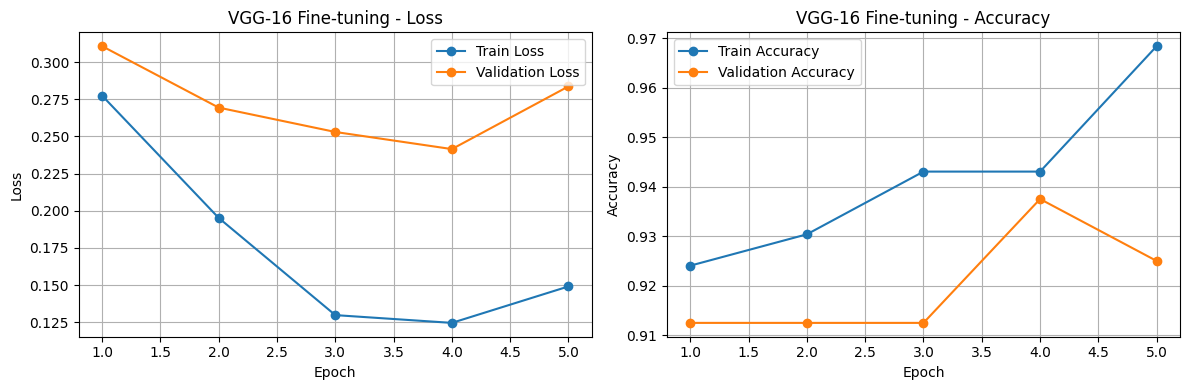

In [ ]:

# 18. Plot VGG-16 learning curves

plot_history(vgg_history_stage2, "VGG-16 Fine-tuning")



## 19. Evaluate Both Models on the Test Set

The test set should be used only for the final evaluation.

We will calculate:
- Test loss
- Test accuracy
- Classification report
- Confusion matrix


In [ ]:

# 19.1 Evaluate AlexNet

alexnet_test_loss, alexnet_test_acc, alex_labels, alex_predictions = evaluate(
    alexnet,
    test_loader,
    criterion
)

print(f"AlexNet Test Loss: {alexnet_test_loss:.4f}")
print(f"AlexNet Test Accuracy: {alexnet_test_acc:.4f}")
print(f"AlexNet Test Accuracy: {alexnet_test_acc * 100:.2f}%")


AlexNet Test Loss: 0.3513
AlexNet Test Accuracy: 0.9197
AlexNet Test Accuracy: 91.97%


In [ ]:

# 19.2 Evaluate VGG-16

vgg_test_loss, vgg_test_acc, vgg_labels, vgg_predictions = evaluate(
    vgg16,
    test_loader,
    criterion
)

print(f"VGG-16 Test Loss: {vgg_test_loss:.4f}")
print(f"VGG-16 Test Accuracy: {vgg_test_acc:.4f}")
print(f"VGG-16 Test Accuracy: {vgg_test_acc * 100:.2f}%")


VGG-16 Test Loss: 0.0930
VGG-16 Test Accuracy: 0.9663
VGG-16 Test Accuracy: 96.63%


In [ ]:

# 20. Classification reports

print("========== AlexNet ==========")
print(
    classification_report(
        alex_labels,
        alex_predictions,
        target_names=class_names,
        zero_division=0
    )
)

print("========== VGG-16 ==========")
print(
    classification_report(
        vgg_labels,
        vgg_predictions,
        target_names=class_names,
        zero_division=0
    )
)


========== AlexNet ==========
              precision    recall  f1-score   support

  Abyssinian       0.87      0.90      0.88        98
      Bengal       0.91      0.86      0.89       100
      Birman       0.91      0.99      0.95       100
      Bombay       1.00      0.93      0.96        88

    accuracy                           0.92       386
   macro avg       0.92      0.92      0.92       386
weighted avg       0.92      0.92      0.92       386

========== VGG-16 ==========
              precision    recall  f1-score   support

  Abyssinian       0.92      0.97      0.95        98
      Bengal       0.95      0.97      0.96       100
      Birman       1.00      0.99      0.99       100
      Bombay       1.00      0.93      0.96        88

    accuracy                           0.97       386
   macro avg       0.97      0.97      0.97       386
weighted avg       0.97      0.97      0.97       386



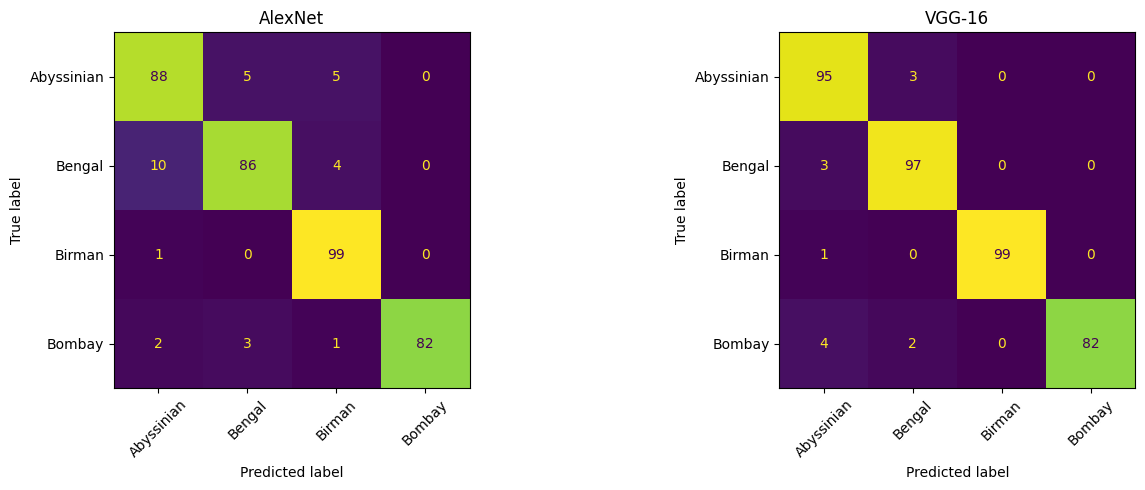

In [ ]:

# 21. Confusion matrices

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_alex = confusion_matrix(alex_labels, alex_predictions)
cm_vgg = confusion_matrix(vgg_labels, vgg_predictions)

ConfusionMatrixDisplay(
    confusion_matrix=cm_alex,
    display_labels=class_names
).plot(ax=axes[0], xticks_rotation=45, colorbar=False)

axes[0].set_title("AlexNet")

ConfusionMatrixDisplay(
    confusion_matrix=cm_vgg,
    display_labels=class_names
).plot(ax=axes[1], xticks_rotation=45, colorbar=False)

axes[1].set_title("VGG-16")

plt.tight_layout()
plt.show()


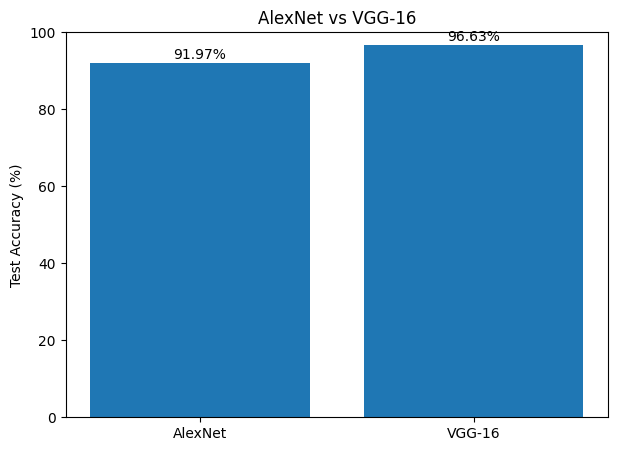

In [ ]:

# 22. Compare final test accuracy

models_to_compare = ["AlexNet", "VGG-16"]
accuracies = [alexnet_test_acc * 100, vgg_test_acc * 100]

plt.figure(figsize=(7, 5))
bars = plt.bar(models_to_compare, accuracies)

plt.ylabel("Test Accuracy (%)")
plt.title("AlexNet vs VGG-16")
plt.ylim(0, 100)

for bar, value in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()



# 23. Intermediate Feature Visualization

A CNN does not directly jump from an input image to a class label.

It progressively transforms the image:

**Input image → edges → textures → shapes → high-level representations → class**

We can inspect the activations produced by intermediate convolutional layers.

For this lab we will visualize:

- **AlexNet:** an early convolutional layer
- **VGG-16:** a deeper convolutional layer

The feature maps can help us understand what the CNN is representing internally.

> **Important:** A feature map is not necessarily a human-interpretable "detector" for one specific object. The visualizations show activations produced by individual learned channels.


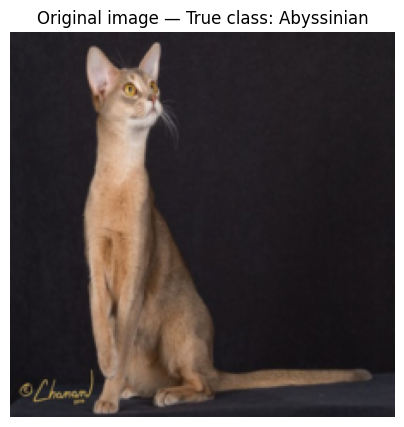

In [ ]:

# 24. Select one test image for feature visualization

sample_image, sample_label = test_dataset[0]

plt.figure(figsize=(5, 5))
display_image = denormalize(sample_image).clamp(0, 1)
plt.imshow(display_image.permute(1, 2, 0))
plt.title(f"Original image — True class: {class_names[sample_label]}")
plt.axis("off")
plt.show()

input_tensor = sample_image.unsqueeze(0).to(device)


In [ ]:

# 25. Helper function to extract intermediate activations

def get_activation(model, layer, input_tensor):
    activation = {}

    def hook_fn(module, inputs, output):
        activation["value"] = output.detach().cpu()

    handle = layer.register_forward_hook(hook_fn)

    model.eval()
    with torch.no_grad():
        _ = model(input_tensor)

    handle.remove()

    return activation["value"]


def visualize_feature_maps(feature_maps, title, max_maps=16):
    feature_maps = feature_maps[0]  # remove batch dimension

    n_maps = min(feature_maps.shape[0], max_maps)

    cols = 4
    rows = int(np.ceil(n_maps / cols))

    plt.figure(figsize=(12, 3 * rows))

    for i in range(n_maps):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(feature_maps[i], cmap="viridis")
        plt.title(f"Channel {i}")
        plt.axis("off")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()



## 26. AlexNet Intermediate Features

AlexNet stores its convolutional feature extractor in:

```python
alexnet.features
```

We will inspect the output of an early convolutional block.

Because `Sequential` indices can vary in interpretation depending on the exact architecture/API version, first inspect the feature extractor.


In [ ]:

# Inspect AlexNet feature extractor

for idx, layer in enumerate(alexnet.features):
    print(idx, layer)


0 Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
1 ReLU(inplace=True)
2 MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
3 Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
4 ReLU(inplace=True)
5 MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
6 Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
7 ReLU(inplace=True)
8 Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
9 ReLU(inplace=True)
10 Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
11 ReLU(inplace=True)
12 MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)


AlexNet feature-map shape: (1, 64, 55, 55)


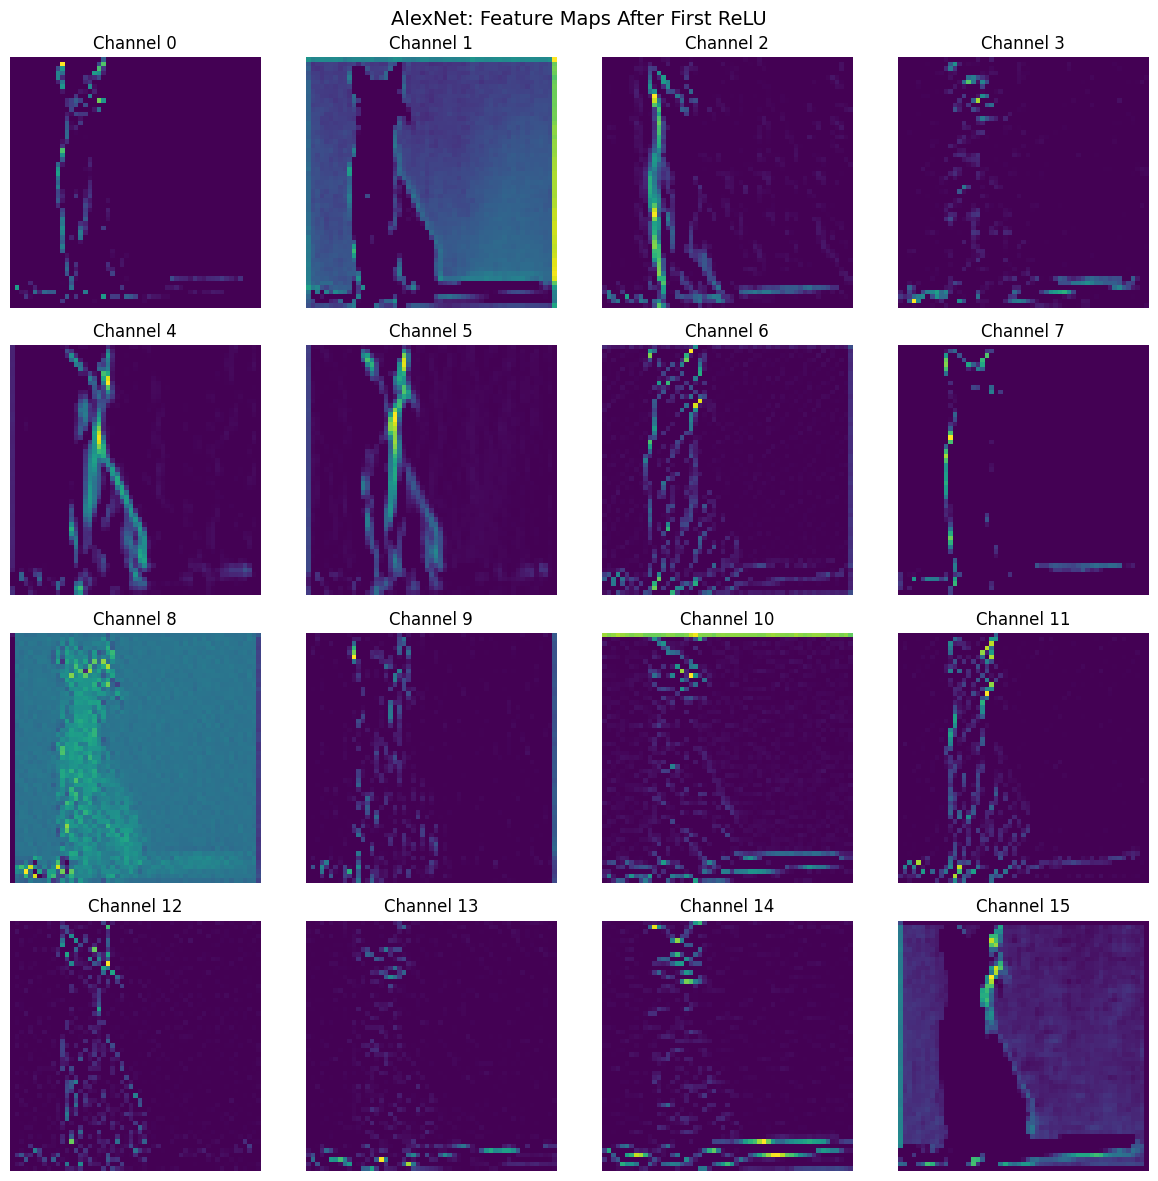

In [ ]:

# Extract an early AlexNet feature representation.
# In the standard torchvision AlexNet, index 1 is the ReLU
# immediately after the first convolution.

alex_feature_maps = get_activation(
    alexnet,
    alexnet.features[1],
    input_tensor
)

print("AlexNet feature-map shape:", tuple(alex_feature_maps.shape))

visualize_feature_maps(
    alex_feature_maps,
    "AlexNet: Feature Maps After First ReLU",
    max_maps=16
)



### Interpretation

The first convolutional layers usually respond to relatively simple visual patterns.

When examining the feature maps, look for:
- bright regions indicating stronger activation
- edge-like structures
- boundaries
- repeated texture patterns

Different channels learn different filters, so the same input image can produce very different activation maps across channels.



## 27. VGG-16 Intermediate Features

VGG-16 stores its convolutional layers in:

```python
vgg16.features
```

VGG has many more convolutional layers than AlexNet.

We will visualize a deeper layer to observe how representations change as we move deeper into the network.


In [ ]:

# Inspect VGG-16 feature extractor

for idx, layer in enumerate(vgg16.features):
    print(idx, layer)


0 Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
1 ReLU(inplace=True)
2 Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
3 ReLU(inplace=True)
4 MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
5 Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
6 ReLU(inplace=True)
7 Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
8 ReLU(inplace=True)
9 MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
10 Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
11 ReLU(inplace=True)
12 Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
13 ReLU(inplace=True)
14 Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
15 ReLU(inplace=True)
16 MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
17 Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
18 ReLU(inplace=True)
19 Conv2d(512, 512, kernel_size=(3, 3)

VGG-16 feature-map shape: (1, 64, 224, 224)


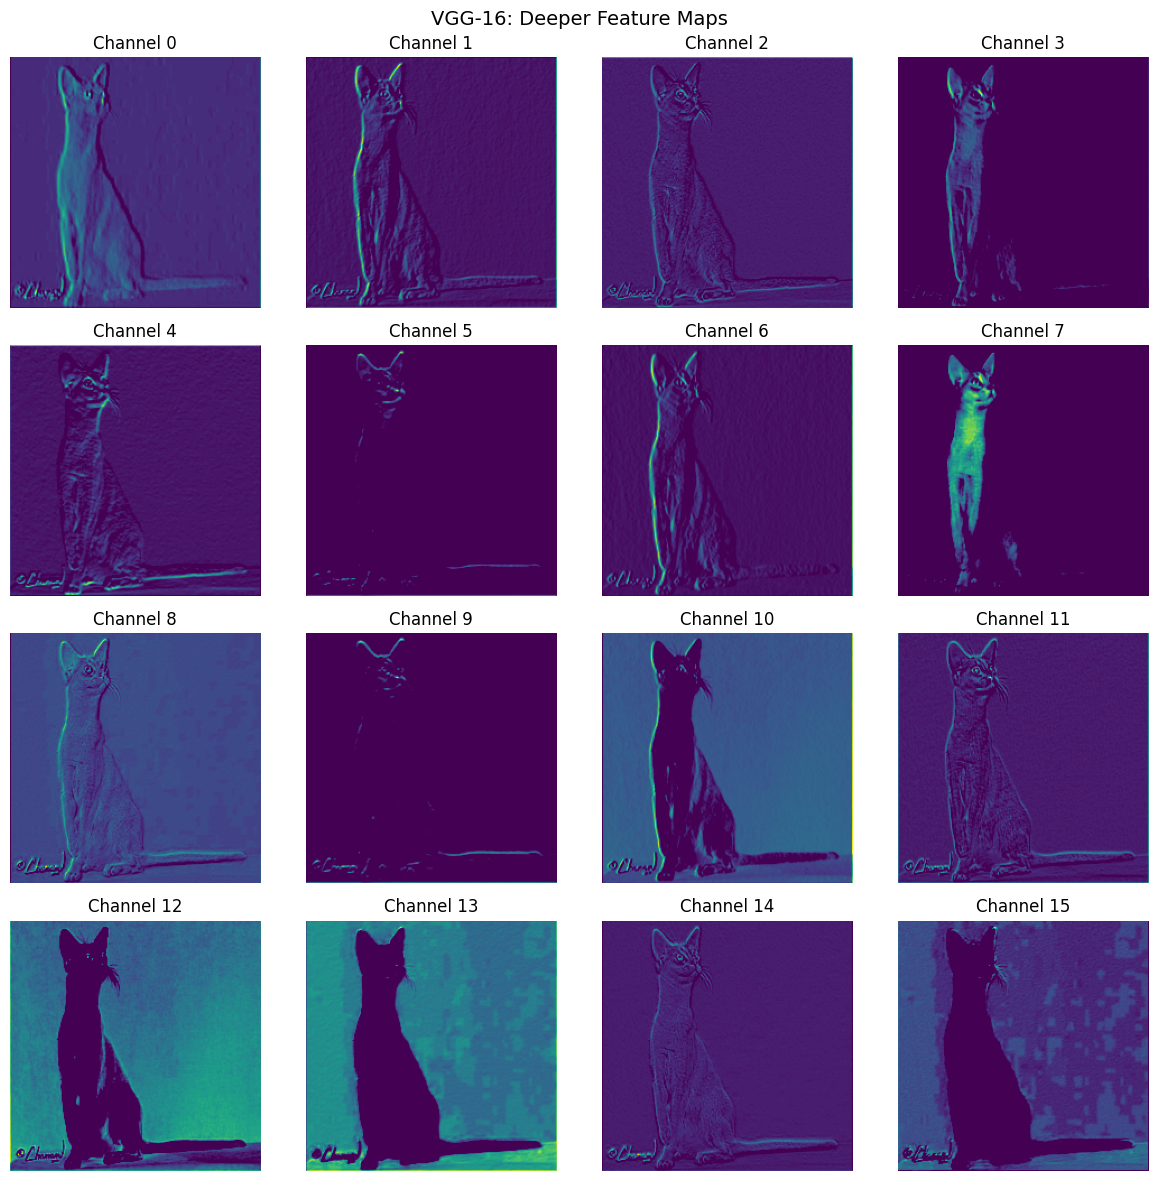

In [ ]:

# In the standard torchvision VGG-16 architecture,
# index 16 corresponds to a ReLU after a deeper convolution.

vgg_feature_maps = get_activation(
    vgg16,
    vgg16.features[1],
    input_tensor
)

print("VGG-16 feature-map shape:", tuple(vgg_feature_maps.shape))

visualize_feature_maps(
    vgg_feature_maps,
    "VGG-16: Deeper Feature Maps",
    max_maps=16
)
